# IQR Outlier Treatment


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [3]:
path = "/content/drive/MyDrive/data/house_price_zscore_practice.csv"

In [5]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv(path)

In [8]:
df.head()

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
0,1040.3,1,1,10.0,0.42,114.78
1,1645.4,3,3,1.3,12.16,201.66
2,19252.0,4,3,0.2,0.30,250.06
3,1764.0,3,2,2.5,3.61,202.62
4,1703.8,3,2,14.3,22.68,188.63


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area_sqft              300 non-null    float64
 1   bedrooms               300 non-null    int64  
 2   bathrooms              300 non-null    int64  
 3   age_years              300 non-null    float64
 4   distance_from_city_km  300 non-null    float64
 5   price_in_thousands     300 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 14.2 KB


In [10]:
df.describe()

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2004.250062,2.996667,2.283333,8.527413,6.942555,223.797809
std,1621.385620,1.083468,0.908740,8.875763,11.391242,118.997876
min,450.000000,1.000000,1.000000,-9.355076,0.300000,12.577959
25%,1461.125000,2.000000,2.000000,2.100000,1.692500,182.372500
50%,1834.600000,3.000000,2.000000,6.100000,4.395000,212.405000
75%,2140.625000,4.000000,3.000000,11.850000,7.885000,245.012500
max,19252.000000,5.000000,5.000000,45.000000,118.673820,1304.037651


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


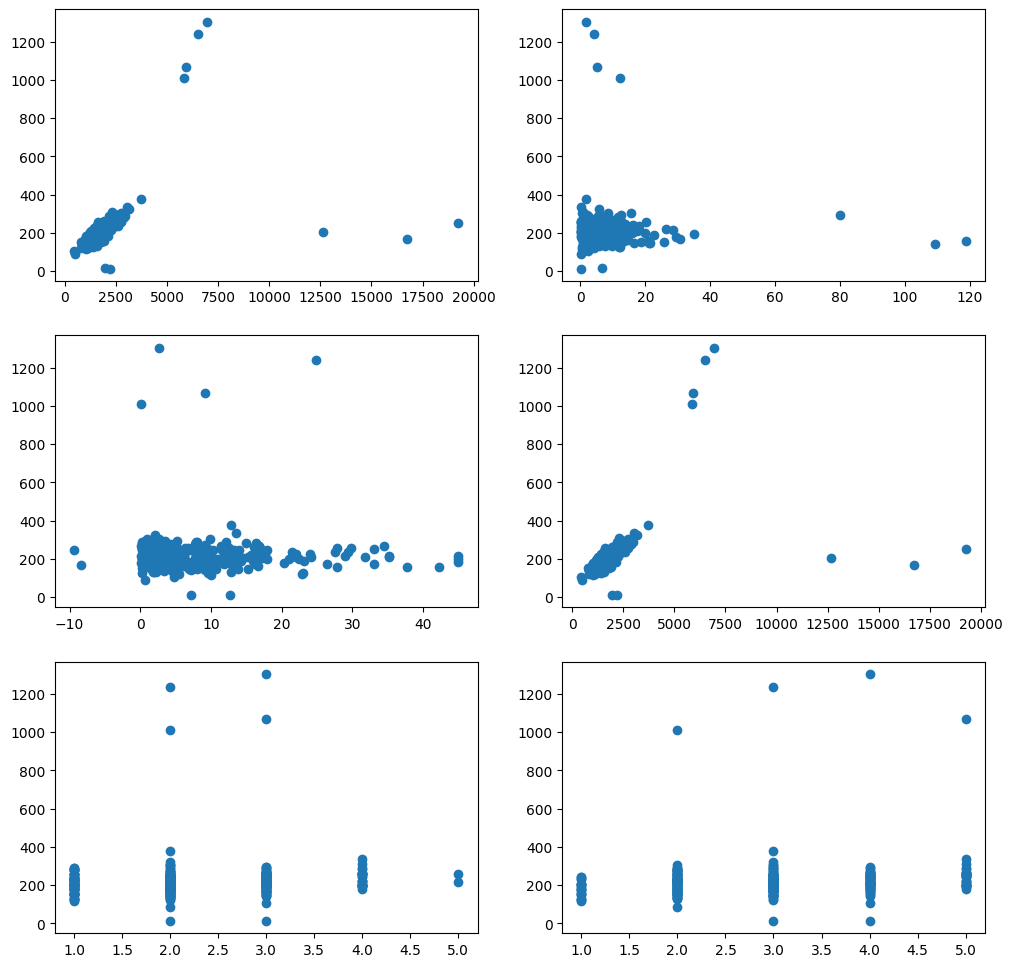

In [14]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12,12)
)

flat = axes.flatten()

flat[0].scatter(df["area_sqft"], df["price_in_thousands"])
flat[1].scatter(df["distance_from_city_km"], df["price_in_thousands"])
flat[2].scatter(df["age_years"], df["price_in_thousands"])
flat[3].scatter(df["area_sqft"], df["price_in_thousands"])
flat[4].scatter(df["bathrooms"], df["price_in_thousands"])
flat[5].scatter(df["bedrooms"], df["price_in_thousands"])


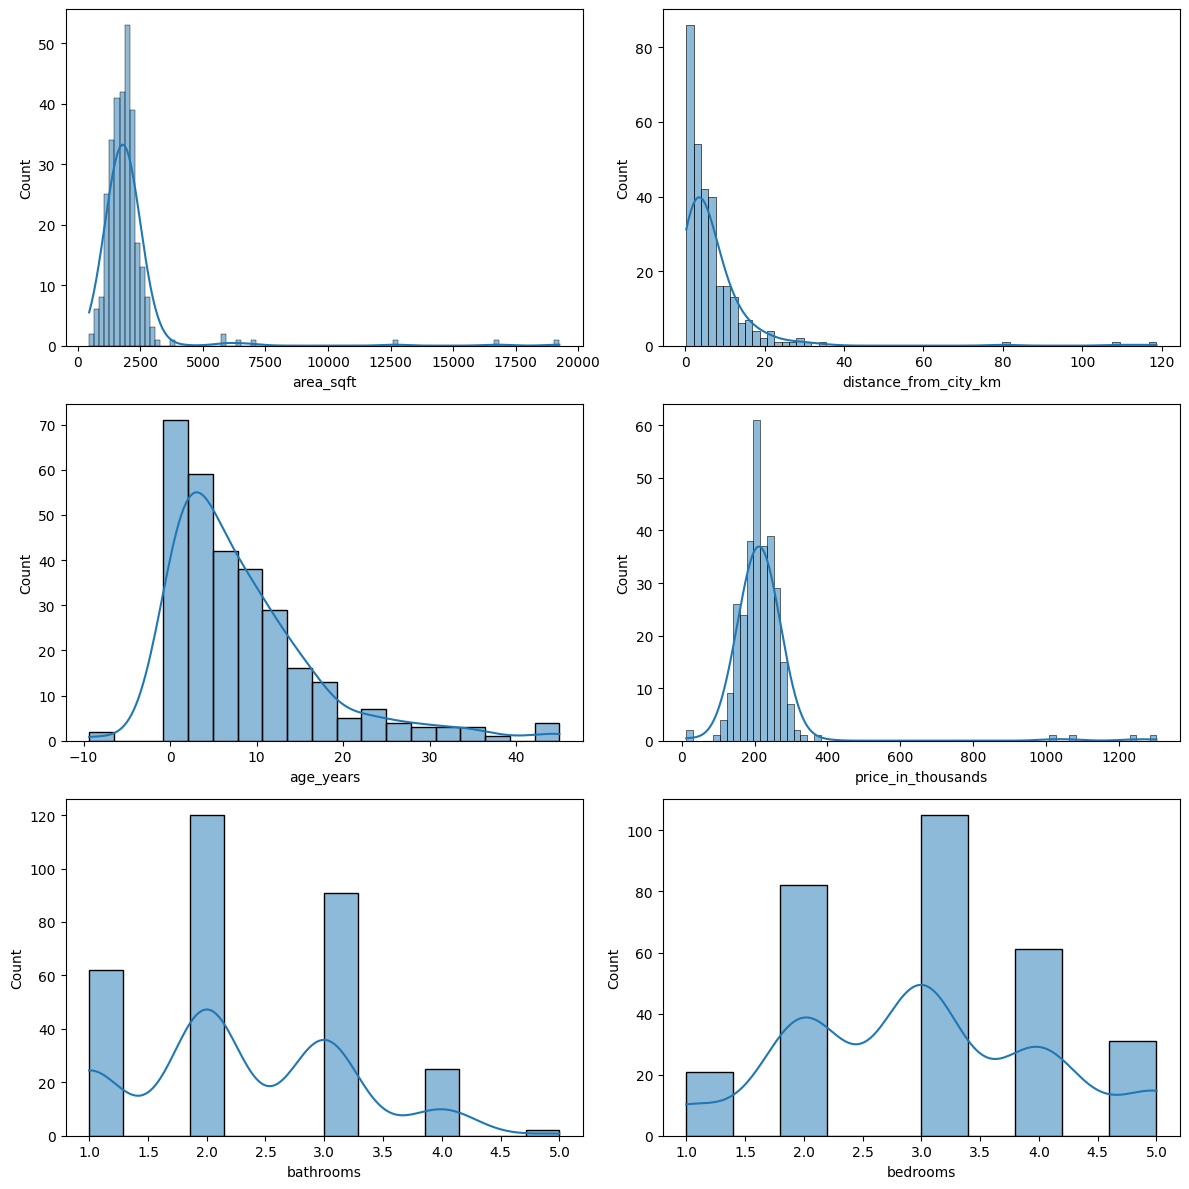

In [15]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12)
)

flat = axes.flatten()

sns.histplot(df["area_sqft"], kde=True, ax=flat[0])
sns.histplot(df["distance_from_city_km"], kde=True, ax=flat[1])
sns.histplot(df["age_years"], kde=True, ax=flat[2])
sns.histplot(df["price_in_thousands"], kde=True, ax=flat[3])
sns.histplot(df["bathrooms"], kde=True, ax=flat[4])
sns.histplot(df["bedrooms"], kde=True, ax=flat[5])

plt.tight_layout()
plt.show()

In [19]:
area_Q1 = df["area_sqft"].quantile(0.25)
area_Q3 = df["area_sqft"].quantile(0.75)
area_IQR = area_Q3 - area_Q1
area_lower = area_Q1 - 1.5 * area_IQR
area_upper = area_Q3 + 1.5 * area_IQR

In [22]:
df_clean  = df
df_clean = df[
    (df["area_sqft"] >= area_lower) &
    (df["area_sqft"] <= area_upper)
]

In [29]:
cols = ["age_years", "distance_from_city_km"]

In [36]:
Q1 = df_clean[cols].quantile(0.25)
Q3 = df_clean[cols].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [40]:
df_clean = df_clean[~((df_clean[cols] < lower) | (df_clean[cols] > upper)).any(axis=1)]

In [41]:
df_clean

,area_sqft,bedrooms,bathrooms,age_years,distance_from_city_km,price_in_thousands
0,1040.3,1,1,10.0,0.42,114.78
1,1645.4,3,3,1.3,12.16,201.66
3,1764.0,3,2,2.5,3.61,202.62
5,1856.8,2,2,2.1,6.56,220.61
6,1111.2,2,2,1.8,5.66,131.60
...,...,...,...,...,...,...
295,2367.8,2,1,4.9,1.93,277.26
296,2301.8,4,3,1.1,16.30,239.21
297,1855.5,5,3,9.1,4.34,247.14
298,1358.1,3,2,20.3,0.30,179.42


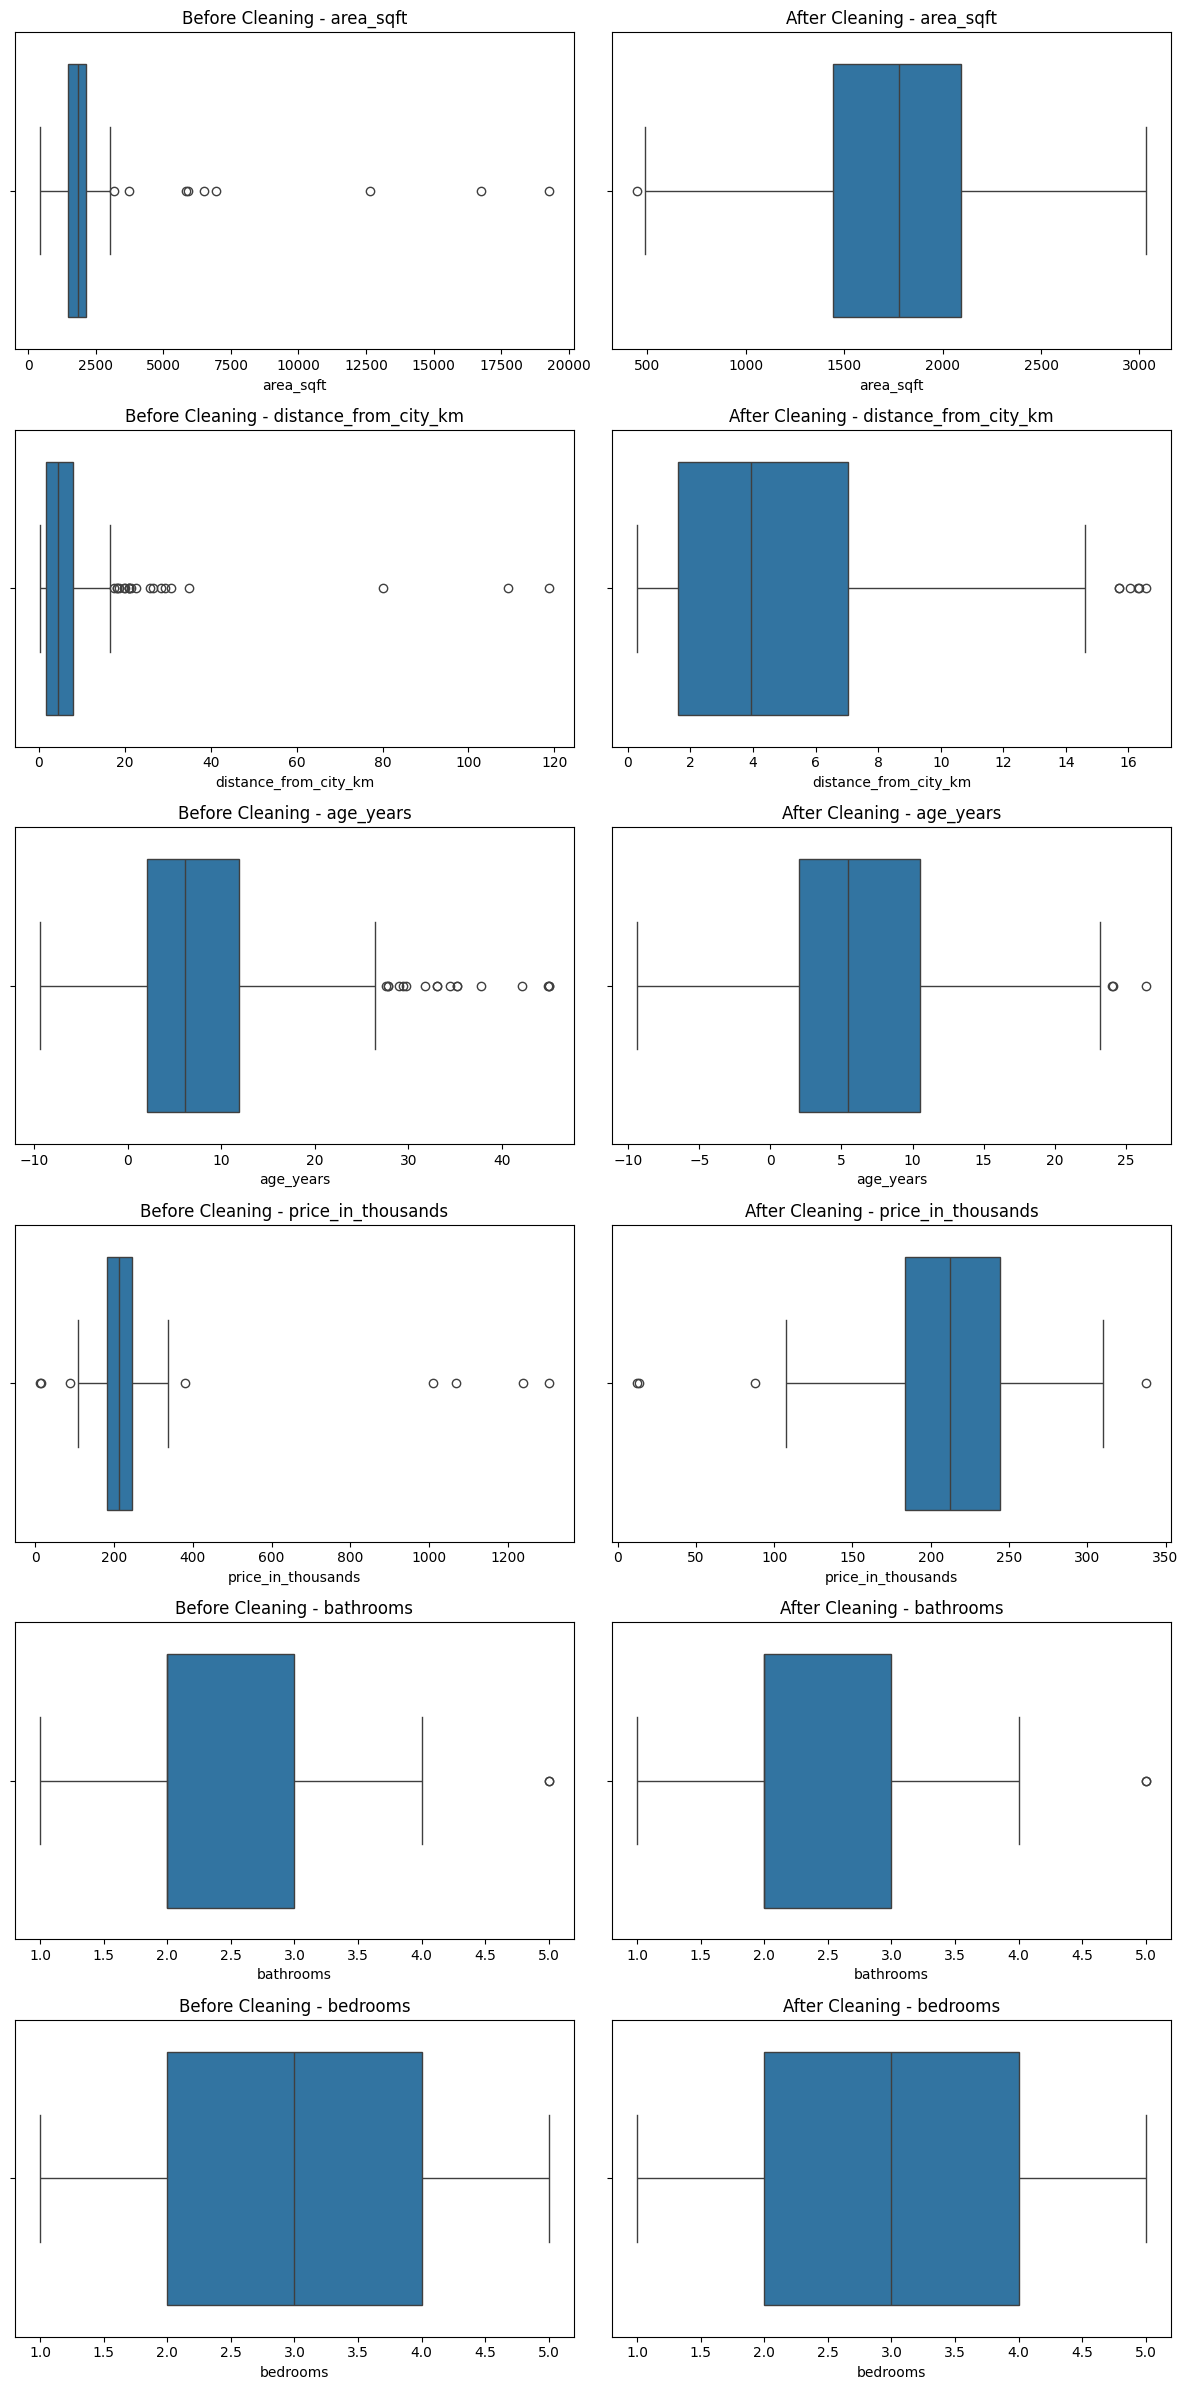

In [54]:


cols = [
    "area_sqft",
    "distance_from_city_km",
    "age_years",
    "price_in_thousands",
    "bathrooms",
    "bedrooms"
]

fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(12, 24)
)

for i, col in enumerate(cols):
    # Left side: Original df
    sns.boxplot(x=df[col], ax=axes[i, 0])
    axes[i, 0].set_title(f"Before Cleaning - {col}")

    # Right side: Cleaned df
    sns.boxplot(x=df_clean[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"After Cleaning - {col}")


plt.tight_layout()
plt.show()

In [59]:
df_clean["distance_from_city_km"] = np.log1p(df_clean["distance_from_city_km"])

/tmp/ipykernel_22333/2225658793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["distance_from_city_km"] = np.log1p(df_clean["distance_from_city_km"])


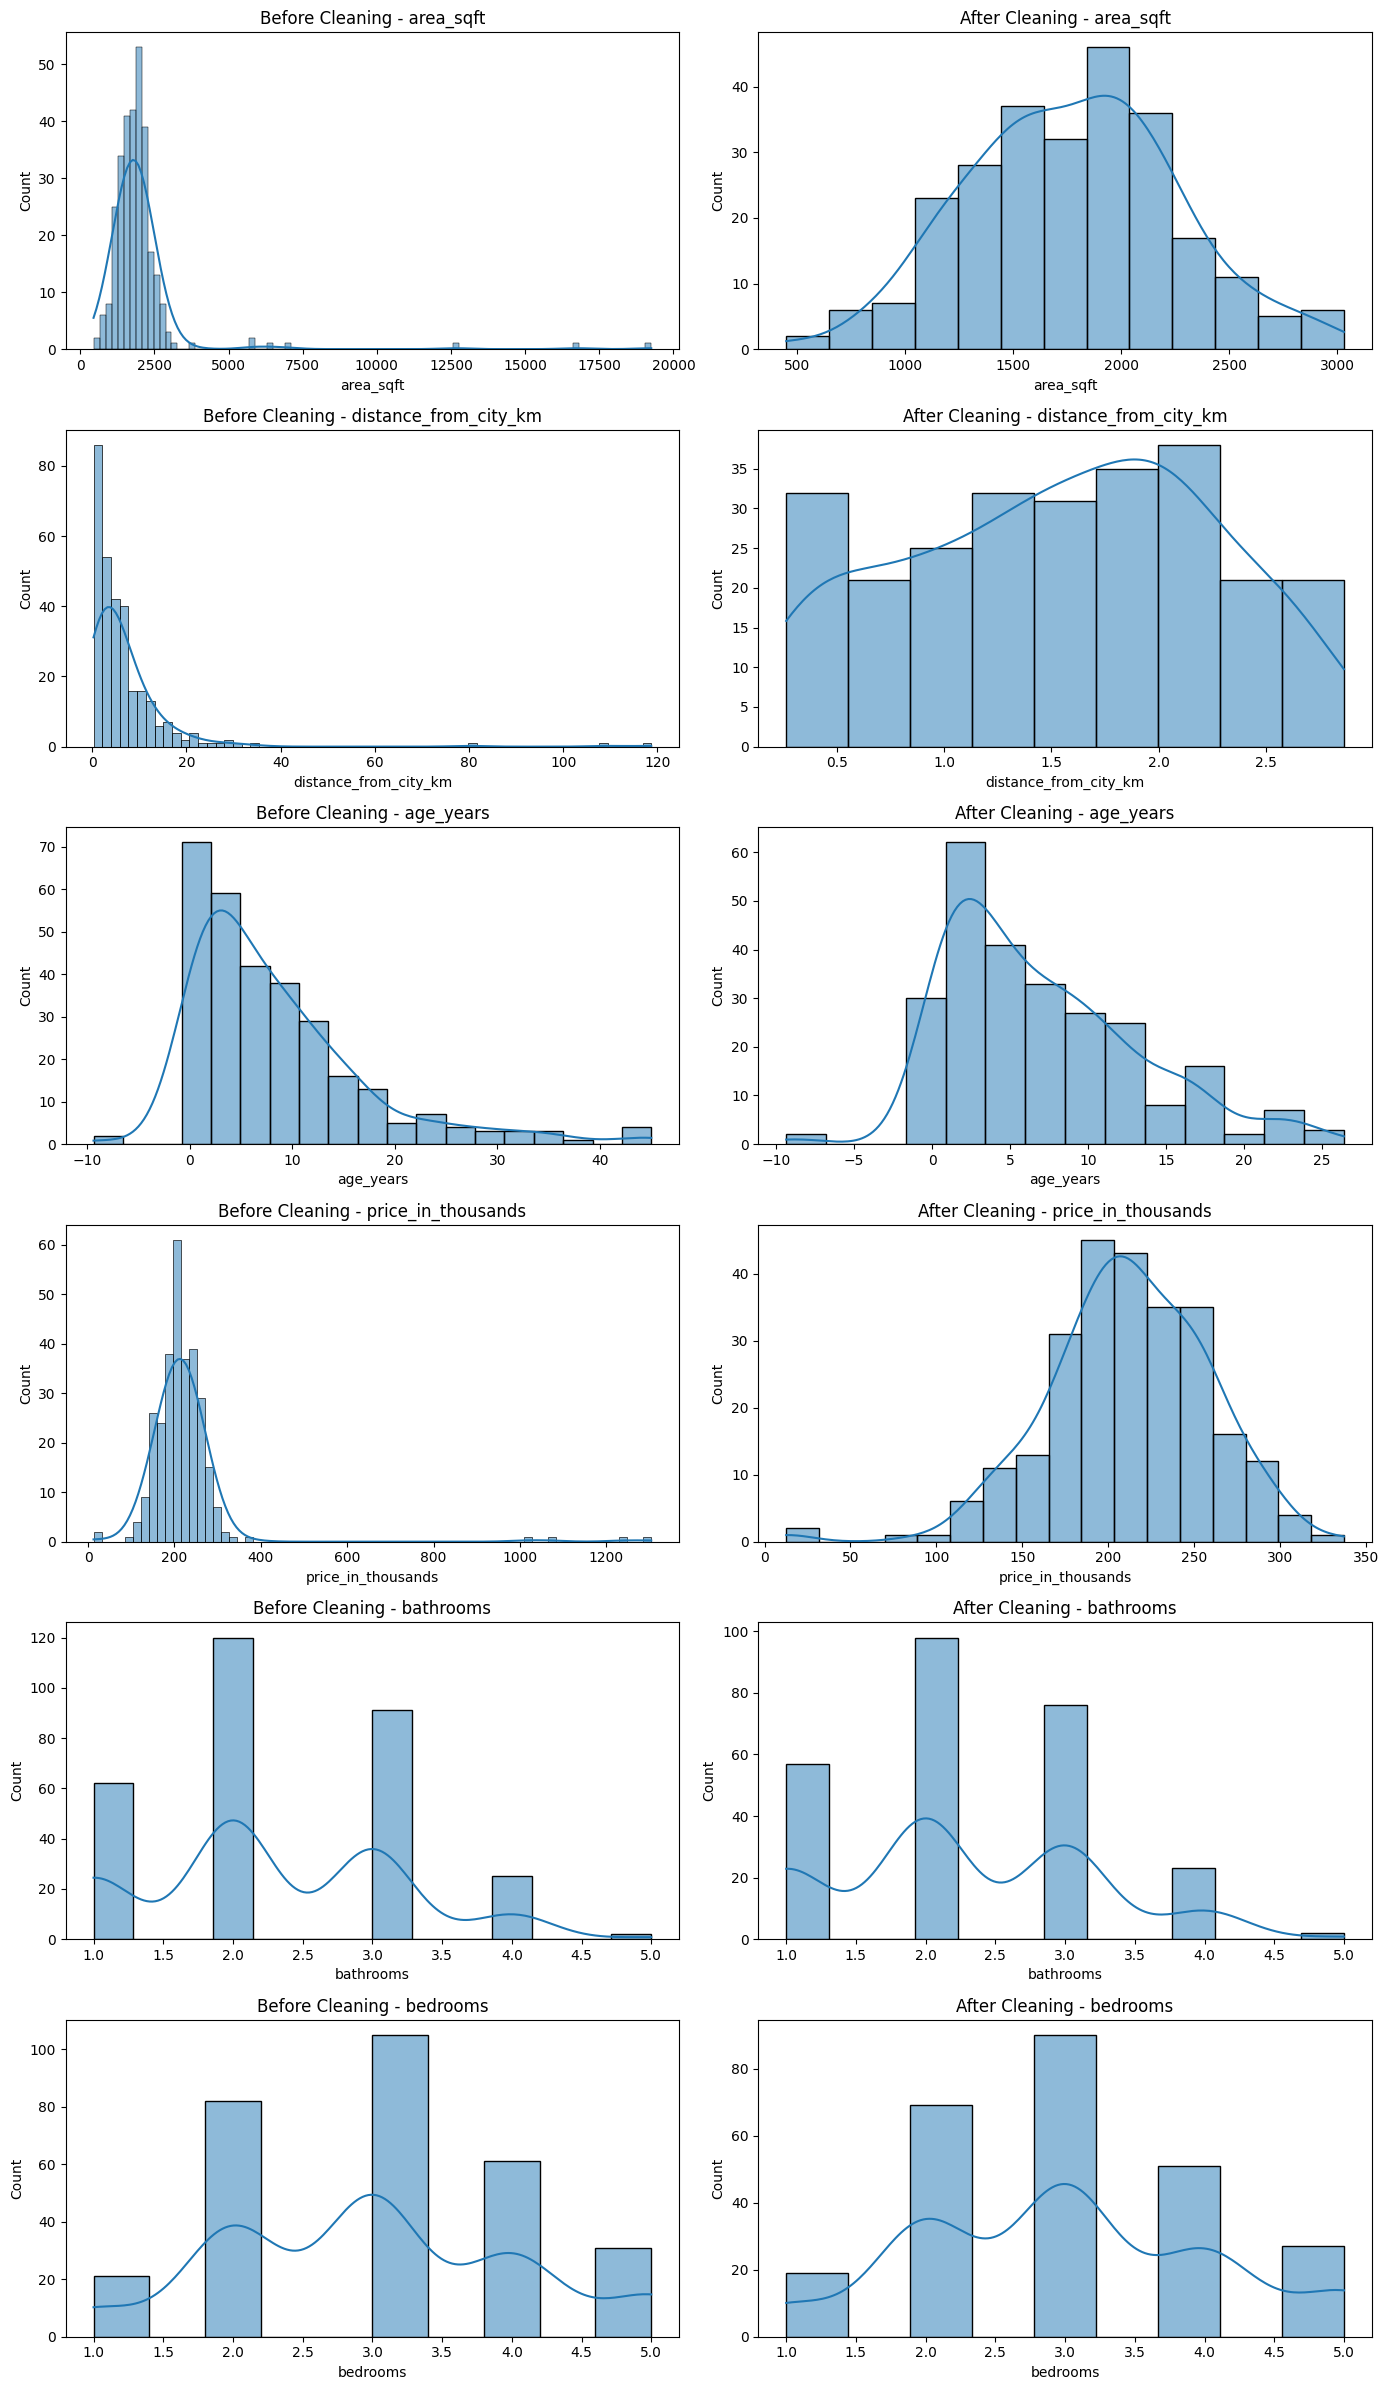

In [60]:


cols = [
    "area_sqft",
    "distance_from_city_km",
    "age_years",
    "price_in_thousands",
    "bathrooms",
    "bedrooms"
]

fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(14, 24)
)

for i, col in enumerate(cols):
    # Left side: Original dataset
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Before Cleaning - {col}")

    # Right side: Cleaned dataset
    sns.histplot(df_clean[col], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"After Cleaning - {col}")


plt.tight_layout()
plt.show()

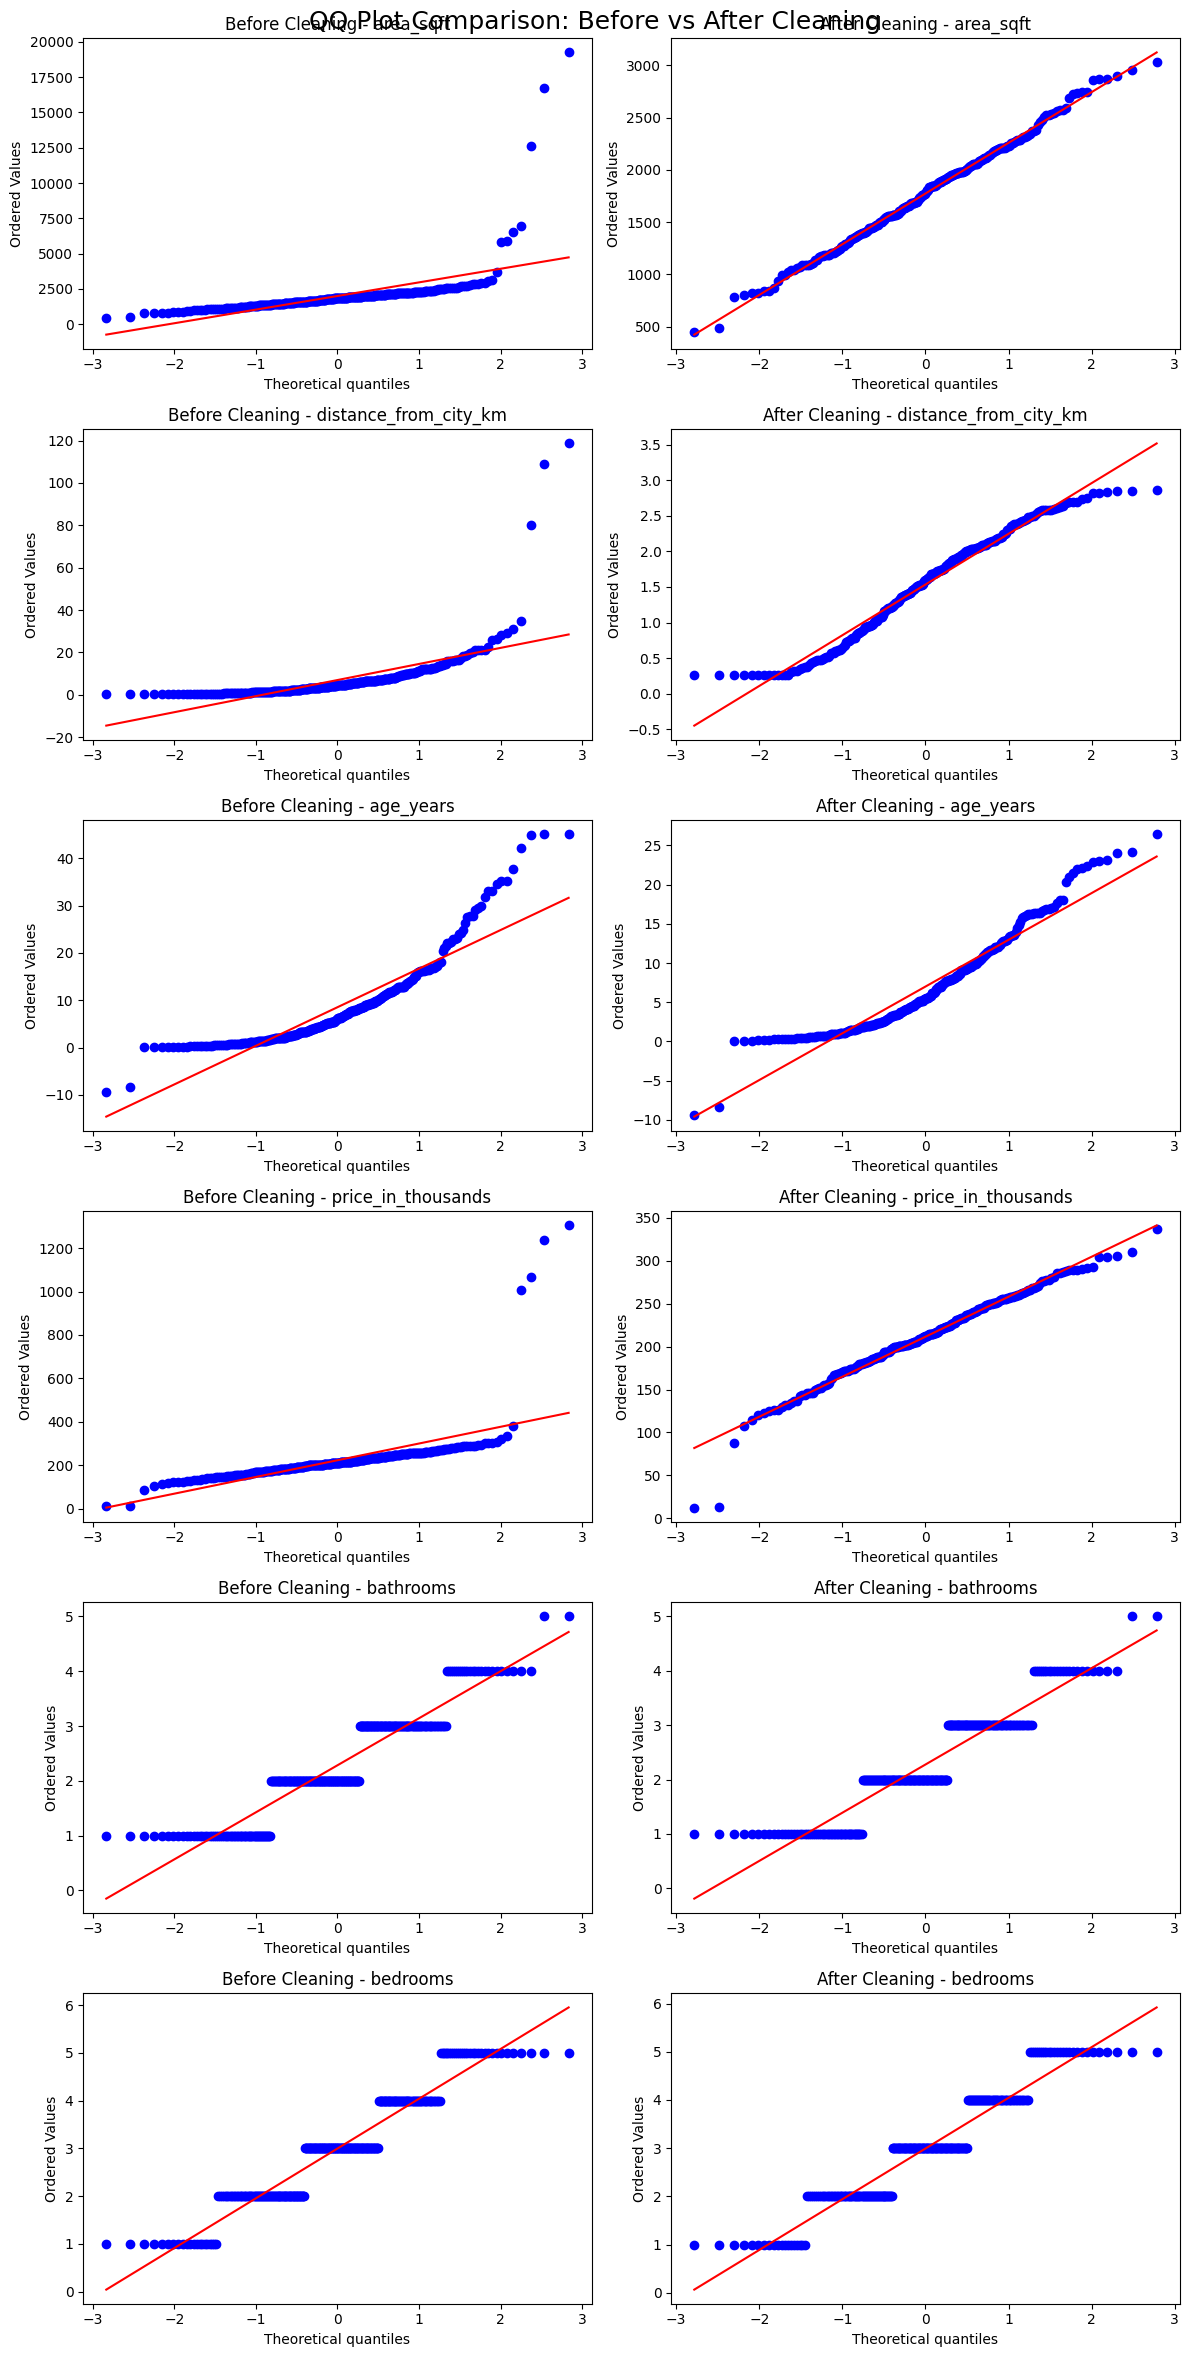

In [61]:
import matplotlib.pyplot as plt
from scipy import stats

cols = [
    "area_sqft",
    "distance_from_city_km",
    "age_years",
    "price_in_thousands",
    "bathrooms",
    "bedrooms"
]

fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(12, 24)
)

for i, col in enumerate(cols):
    # Left: Original dataset
    stats.probplot(df[col], dist="norm", plot=axes[i, 0])
    axes[i, 0].set_title(f"Before Cleaning - {col}")

    # Right: Cleaned dataset
    stats.probplot(df_clean[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"After Cleaning - {col}")

fig.suptitle("QQ Plot Comparison: Before vs After Cleaning", fontsize=18)

plt.tight_layout()
plt.show()

In [57]:
df_clean.shape

(256, 6)

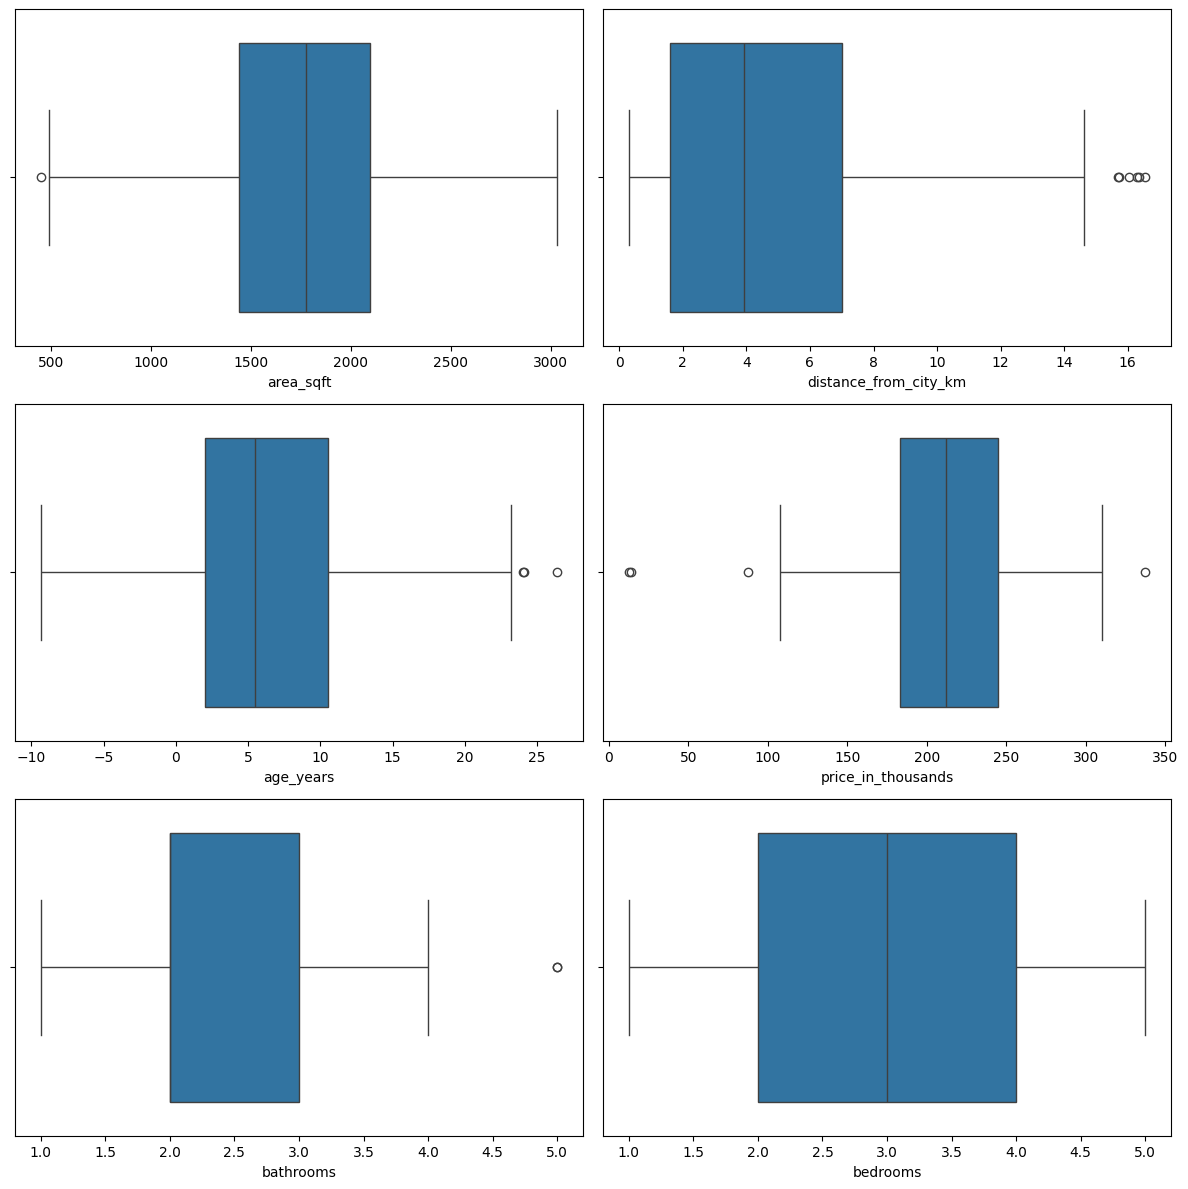

In [51]:


fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12)
)

flat = axes.flatten()

sns.boxplot(x=df_clean["area_sqft"], ax=flat[0])
sns.boxplot(x=df_clean["distance_from_city_km"], ax=flat[1])
sns.boxplot(x=df_clean["age_years"], ax=flat[2])
sns.boxplot(x=df_clean["price_in_thousands"], ax=flat[3])
sns.boxplot(x=df_clean["bathrooms"], ax=flat[4])
sns.boxplot(x=df_clean["bedrooms"], ax=flat[5])

plt.tight_layout()
plt.show()

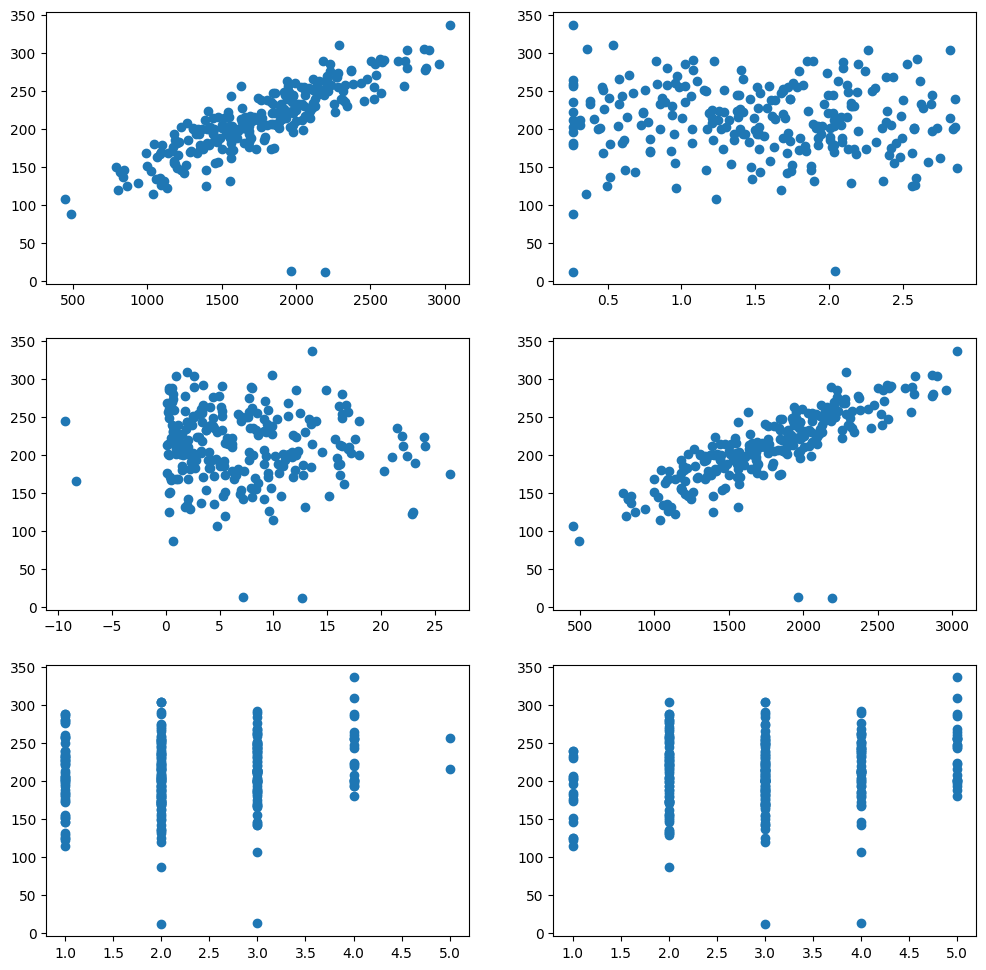

In [68]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12,12)
)

flat = axes.flatten()

flat[0].scatter(df_clean["area_sqft"], df_clean["price_in_thousands"])
flat[1].scatter(df_clean["distance_from_city_km"], df_clean["price_in_thousands"])
flat[2].scatter(df_clean["age_years"], df_clean["price_in_thousands"])
flat[3].scatter(df_clean["area_sqft"], df_clean["price_in_thousands"])
flat[4].scatter(df_clean["bathrooms"], df_clean["price_in_thousands"])
flat[5].scatter(df_clean["bedrooms"], df_clean["price_in_thousands"])


In [63]:
from sklearn.model_selection import train_test_split

# Features (independent variables)
X = df_clean[[
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "age_years",
    "distance_from_city_km"
]]

# Target (dependent variable)
y = df_clean["price_in_thousands"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% for testing
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (204, 5)
X_test: (52, 5)
y_train: (204,)
y_test: (52,)


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


In [66]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8768730032955182